## Pypsa to model Ghana's 2024 power system and test contingencies


Ghana 2024 Power System - Baseline Dispatch
============================================
Vanilla PyPSA single-node model.
Real generator fleet from Energy Commission Statistical Bulletin.
Real hourly demand profile constructed from WEM Bulletins.
Marginal costs: heat_rate x fuel_price / 1000 (USD/MWh).
Validation targets from Statistical Bulletin 2025 .
 
Author:  Engr. Kwaku Duah


In [10]:
import pypsa
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [11]:
# paths

DEMAND_PATH    = "/data/Pypsa-Research/data/demand/Ghana_2024_Hourly_Demand_MW.csv"
GENERATOR_FLEET_PATH     = "/data/Pypsa-Research/data/generators/ghana_fleet_2024.csv"
RESULTS_PATH   = "/data/Pypsa-Research/results/"

In [12]:
# Demand/ Load Profile
demand = pd.read_csv(DEMAND_PATH, index_col=0, parse_dates=True)
demand.index.name = "snapshot"

In [13]:
# 2024 is a leap year - drop Feb 29 to standardise to 8760 hours
demand = demand[~((demand.index.month == 2) & (demand.index.day == 29))]
assert len(demand) == 8760, f"Expected 8760, got {len(demand)}"
print(f"Demand loaded: {len(demand)} hours")
print(f"  Peak:    {demand['demand_MW'].max():.1f} MW  (ref: 3,659.7 MW)")
print(f"  Average: {demand['demand_MW'].mean():.1f} MW")
print(f"  Annual:  {demand['demand_MW'].sum()/1000:.1f} GWh  (ref: 20,303 GWh)")

Demand loaded: 8760 hours
  Peak:    3659.7 MW  (ref: 3,659.7 MW)
  Average: 2297.7 MW
  Annual:  20127.5 GWh  (ref: 20,303 GWh)


In [14]:
fleet = pd.read_csv(GENERATOR_FLEET_PATH, comment="#")
 
# Fix spacing issues from CSV - strip all string columns
fleet.columns = fleet.columns.str.strip()
fleet["name"]    = fleet["name"].str.strip()
fleet["carrier"] = fleet["carrier"].str.strip().str.lower()
fleet["status"]  = fleet["status"].str.strip()
 
# Parse numeric columns
for col in ["p_nom_mw", "marginal_cost_usd_mwh", "capital_cost", "p_max_pu"]:
    fleet[col] = pd.to_numeric(fleet[col], errors="coerce")
 
# Drop blank spacer rows
fleet = fleet.dropna(subset=["p_nom_mw"]).reset_index(drop=True)
 
print(f"\nFleet loaded: {len(fleet)} generators")
print(f"  Operational: {(fleet['status']=='operational').sum()}")
print(f"  Offline:     {(fleet['status']=='offline').sum()}")
print(f"  Total installed capacity: {fleet['p_nom_mw'].sum():.1f} MW  (ref: 5,749 MW)")
print(f"\n{fleet[['name','carrier','p_nom_mw','marginal_cost_usd_mwh','p_max_pu','status']].to_string(index=False)}")


Fleet loaded: 26 generators
  Operational: 24
  Offline:     2
  Total installed capacity: 5936.1 MW  (ref: 5,749 MW)

              name carrier  p_nom_mw  marginal_cost_usd_mwh  p_max_pu      status
          Akosombo   hydro    1020.0                   0.00       1.0 operational
             Kpong   hydro     160.0                   0.00       1.0 operational
               Bui   hydro     404.0                   0.00       1.0 operational
         Bui_Solar   solar      55.0                   0.00       1.0 operational
   VRA_Kaleo_Solar   solar      29.0                   0.00       1.0 operational
VRA_Navrongo_Solar   solar       2.5                   0.00       1.0 operational
   VRA_Lawra_Solar   solar       6.5                   0.00       1.0 operational
         BXC_Solar   solar      20.0                   0.00       1.0 operational
    Meinergy_Solar   solar      20.0                   0.00       1.0 operational
             TAPCO     gas     330.0                  65.57 

In [15]:
# Initialise network
n = pypsa.Network(name="Ghana-2024-Baseline")
n.set_snapshots(demand.index)
 


In [16]:
# Attach bus - Ghana only/domestic system excluding exports

n.add("Bus", "Ghana", carrier="AC", unit="MW")
 
# Attach load
n.add("Load", "Ghana_load",
      bus="Ghana",
      p_set=demand["demand_MW"])

In [17]:
# Add all generators from fleet
for _, row in fleet.iterrows():
    n.add(
        "Generator", row["name"],
        bus="Ghana",
        carrier=row["carrier"],
        p_nom=row["p_nom_mw"],
        marginal_cost=row["marginal_cost_usd_mwh"],
        capital_cost=row["capital_cost"],
        p_max_pu=row["p_max_pu"],   # offline plants already 0.0 in CSV
    )

In [18]:
# Physical solar constraints
# Solar capacity factor - Ghana latitude ~7°N
# Solar generates only between 06:00 and 18:00, peaks at noon
# sin curve approximation of irradiance profile
solar_cf = pd.Series(
    [max(0.0, np.sin(np.pi * (h - 6) / 12)) if 6 <= h <= 18 else 0.0
     for h in demand.index.hour],
    index=demand.index
)
for gen in n.generators.index[n.generators.carrier == "solar"]:
    n.generators_t.p_max_pu[gen] = solar_cf

In [19]:
# Helper: expand monthly CF dict to hourly timeseries
def monthly_cf(cf_dict, index):
    return pd.Series(index.month, index=index).map(cf_dict).astype(float)

# Akosombo 2024 actual month-end elevations - Statistical Bulletin Table 3.11
akosombo_levels_2024 = {
    1:273, 2:272, 3:270, 4:268,
    5:266, 6:265, 7:265, 8:264,
    9:265, 10:271, 11:271, 12:269
}

# Bui 2024 — Statistical Bulletin Table 3.12
bui_levels_2024 = {
    1:579, 2:558, 3:551, 4:548,
    5:546, 6:546, 7:549, 8:556,
    9:571, 10:593, 11:591, 12:587
}

# Normalise to capacity factor: (level - min) / (max - min)
# Akosombo: min=240ft, max=286.86ft
# Bui:      min=550ft, max=610ft
akosombo_cf = {
    m: max(0.0, round((lv - 240) / (286.86 - 240), 3))
    for m, lv in akosombo_levels_2024.items()
}


bui_cf = {
    m: max(0.0, round((lv - 550) / (600 - 550), 3))
    for m, lv in bui_levels_2024.items()
}
# depends on Akosombo
kpong_cf = {m: round(v * 0.95, 3) for m, v in akosombo_cf.items()}

print("Akosombo CFs:", akosombo_cf)
print("Bui CFs:",      bui_cf)
print("Kpong CFs:",    kpong_cf)

# Apply to network
n.generators_t.p_max_pu["Akosombo"] = monthly_cf(akosombo_cf, demand.index)
n.generators_t.p_max_pu["Kpong"]    = monthly_cf(kpong_cf,    demand.index)
n.generators_t.p_max_pu["Bui"]      = monthly_cf(bui_cf,      demand.index)

Akosombo CFs: {1: 0.704, 2: 0.683, 3: 0.64, 4: 0.598, 5: 0.555, 6: 0.534, 7: 0.534, 8: 0.512, 9: 0.534, 10: 0.662, 11: 0.662, 12: 0.619}
Bui CFs: {1: 0.58, 2: 0.16, 3: 0.02, 4: 0.0, 5: 0.0, 6: 0.0, 7: 0.0, 8: 0.12, 9: 0.42, 10: 0.86, 11: 0.82, 12: 0.74}
Kpong CFs: {1: 0.669, 2: 0.649, 3: 0.608, 4: 0.568, 5: 0.527, 6: 0.507, 7: 0.507, 8: 0.486, 9: 0.507, 10: 0.629, 11: 0.629, 12: 0.588}


In [20]:
#  OPTIMISE 
print("\nRunning dispatch optimisation...")
status, condition = n.optimize(solver_name="highs")
print(f"  Status: {status} | {condition}")
print(f"  Total system cost: USD {n.objective/1e6:.2f} million")

Index(['Akosombo', 'Kpong', 'Bui', 'Bui_Solar', 'VRA_Kaleo_Solar',
       'VRA_Navrongo_Solar', 'VRA_Lawra_Solar', 'BXC_Solar', 'Meinergy_Solar',
       'TAPCO', 'TICO', 'SAPP', 'TT1PP', 'TT2PP', 'CENIT', 'Karpower', 'AMERI',
       'Twin_City', 'Cenpower', 'AKSA', 'KTPP', 'Early_Power', 'Genser',
       'Bridge_Power', 'Takoradi_T3', 'Safisana'],
      dtype='object', name='Generator')
Index(['Ghana'], dtype='object', name='Bus')



Running dispatch optimisation...


Index(['Akosombo', 'Kpong', 'Bui', 'Bui_Solar', 'VRA_Kaleo_Solar',
       'VRA_Navrongo_Solar', 'VRA_Lawra_Solar', 'BXC_Solar', 'Meinergy_Solar',
       'TAPCO', 'TICO', 'SAPP', 'TT1PP', 'TT2PP', 'CENIT', 'Karpower', 'AMERI',
       'Twin_City', 'Cenpower', 'AKSA', 'KTPP', 'Early_Power', 'Genser',
       'Bridge_Power', 'Takoradi_T3', 'Safisana'],
      dtype='object', name='Generator')
Index(['Ghana'], dtype='object', name='Bus')
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 1/1 [00:00<00:00,  1.86it/s]
INFO:linopy.io: Writing time: 3.26s


Running HiGHS 1.11.0 (git hash: n/a): Copyright (c) 2025 HiGHS under MIT licence terms
LP   linopy-problem-dccuosli has 464280 rows; 227760 cols; 683280 nonzeros
Coefficient ranges:
  Matrix [1e+00, 1e+00]
  Cost   [1e+01, 1e+02]
  Bound  [0e+00, 0e+00]
  RHS    [3e-16, 4e+03]
Presolving model
8760 rows, 178842 cols, 178842 nonzeros  0s
8760 rows, 131400 cols, 131400 nonzeros  0s
Dependent equations search running on 8760 equations with time limit of 1000.00s
Dependent equations search removed 0 rows and 0 nonzeros in 0.01s (limit = 1000.00s)
8760 rows, 131400 cols, 131400 nonzeros  0s
Presolve : Reductions: rows 8760(-455520); columns 131400(-96360); elements 131400(-551880)
Solving the presolved LP
Using EKK dual simplex solver - serial
  Iteration        Objective     Infeasibilities num(sum)
          0     0.0000000000e+00 Pr: 8760(2.01275e+07) 1s
       8760     8.1605599483e+08 Pr: 0(0) 1s
Solving the original LP from the solution after postsolve
Model name          : linopy-pro

INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 227760 primals, 464280 duals
Objective: 8.16e+08
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper were not assigned to the network.


  Status: ok | optimal
  Total system cost: USD 816.06 million


In [21]:
#  GENERATION MIX WITH CONSTRAINTS 
# Strip carrier names (safety)
n.generators.carrier = n.generators.carrier.str.strip().str.lower()

gen_by_carrier = (
    n.generators_t.p.sum()
    .groupby(n.generators.carrier)
    .sum() / 1000   # GWh
)
total_gen = gen_by_carrier.sum()

# Validation against Statistical Bulletin 2025
ref = {"hydro": 39.0, "gas": 60.3, "solar": 0.71}
print(f"{'Carrier':<10} {'GWh':>10} {'Share %':>10}  {'Bulletin %':>12}  {'Diff':>6}")
print("-" * 56)
for carrier, gwh in gen_by_carrier.items():
    share = gwh / total_gen * 100
    r     = ref.get(carrier, "-")
    diff  = f"{share - r:+.1f}" if isinstance(r, float) else "-"
    print(f"{carrier:<10} {gwh:>10.1f} {share:>10.1f}  {str(r):>12}  {diff:>6}")
print(f"\n  Total: {total_gen:.1f} GWh")

# What the constraints actually limited hydro to
print(f"\nHydro constraint check:")
print(f"  Akosombo max possible: {1020 * sum(akosombo_cf.values())/12:.0f} MW avg")
print(f"  Actual Akosombo dispatch: {n.generators_t.p['Akosombo'].mean():.0f} MW avg")
print(f"  Bui actual dispatch: {n.generators_t.p['Bui'].mean():.0f} MW avg")

Carrier           GWh    Share %    Bulletin %    Diff
--------------------------------------------------------
biogas            0.9        0.0             -       -
gas           12469.3       62.0          60.3    +1.7
hydro          7288.6       36.2          39.0    -2.8
solar           368.7        1.8          0.71    +1.1

  Total: 20127.5 GWh

Hydro constraint check:
  Akosombo max possible: 615 MW avg
  Actual Akosombo dispatch: 615 MW avg
  Bui actual dispatch: 126 MW avg


In [22]:
# Define these before plotting
total_load = n.loads_t.p.sum(axis=1)
gen_hourly = n.generators_t.p.sum(axis=1)
unmet      = (total_load - gen_hourly).clip(lower=0)

# Generation by carrier
n.generators.carrier = n.generators.carrier.str.strip().str.lower()
gen_by_carrier = (
    n.generators_t.p.sum()
    .groupby(n.generators.carrier)
    .sum() / 1000
)
total_gen = gen_by_carrier.sum()

# Emissions
co2 = {"hydro": 0.0, "solar": 0.0, "gas": 0.202, "biogas": 0.0}
total_co2 = sum(
    n.generators_t.p[g].sum()
    * co2.get(n.generators.loc[g, "carrier"], 0)
    for g in n.generators.index
)
grid_ef = total_co2 / (total_gen * 1000)

# Model shares for comparison
ref = {"hydro": 39.0, "gas": 60.3, "solar": 0.71}
model_shares = {c: gen_by_carrier.get(c, 0) / total_gen * 100 for c in ref}

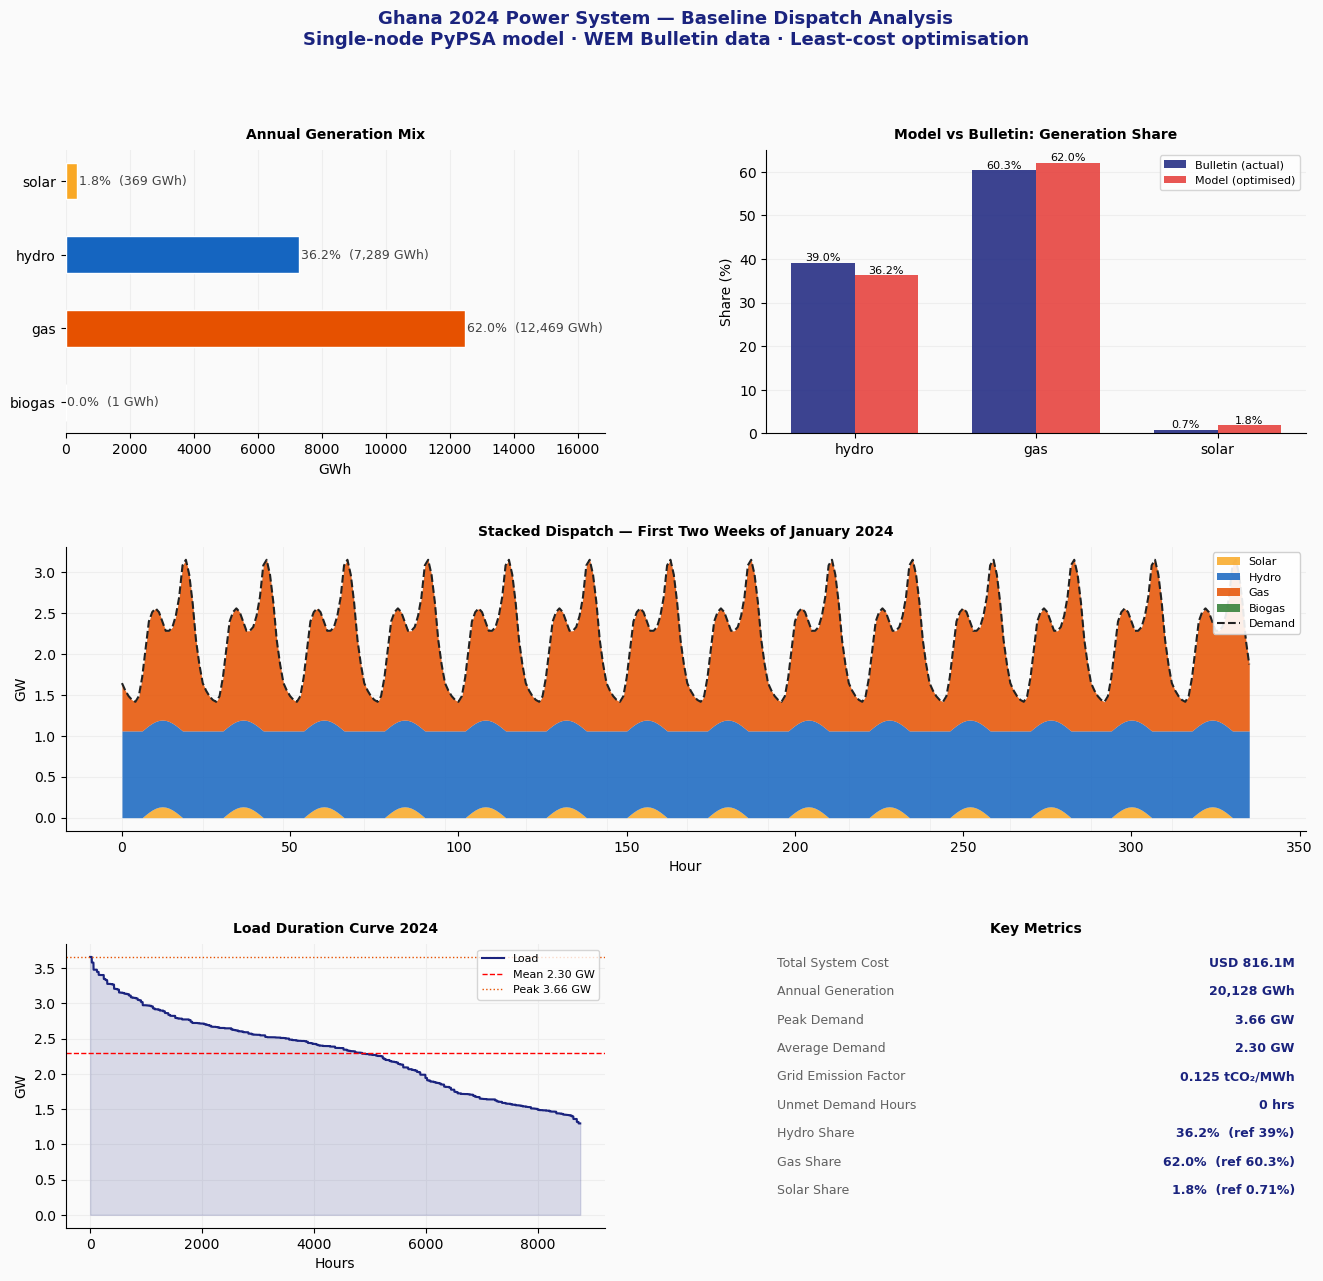

Saved to /data/Pypsa-Research/results/baseline_2024.png


In [ ]:

import matplotlib.gridspec as gridspec


# ── COLOUR PALETTE 
C = {
    "hydro":  "#1565C0",   # deep blue
    "gas":    "#E65100",   # deep orange  
    "solar":  "#F9A825",   # amber
    "biogas": "#2E7D32",   # dark green
    "demand": "#212121",   # near black
    "bg":     "#FAFAFA",
    "grid":   "#EEEEEE",
}

fig = plt.figure(figsize=(16, 14), facecolor=C["bg"])
fig.suptitle(
    "Ghana 2024 Power System — Baseline Dispatch Analysis\n"
    "Single-node PyPSA model · WEM Bulletin data · Least-cost optimisation",
    fontsize=13, fontweight="bold", y=0.98, color="#1A237E"
)

gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.40, wspace=0.30)

# ── CHART 1: Generation mix — horizontal bar with % labels
ax1 = fig.add_subplot(gs[0, 0])
ax1.set_facecolor(C["bg"])

carriers  = list(gen_by_carrier.index)
gwh_vals  = list(gen_by_carrier.values)
shares    = [v / total_gen * 100 for v in gwh_vals]
bar_colors = [C.get(c, "#90A4AE") for c in carriers]

bars = ax1.barh(carriers, gwh_vals, color=bar_colors, height=0.5, edgecolor="white")
for bar, share, gwh in zip(bars, shares, gwh_vals):
    ax1.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
             f"{share:.1f}%  ({gwh:,.0f} GWh)",
             va="center", fontsize=9, color="#424242")

ax1.set_title("Annual Generation Mix", fontweight="bold", fontsize=10, pad=8)
ax1.set_xlabel("GWh")
ax1.set_xlim(0, max(gwh_vals) * 1.35)
ax1.grid(axis="x", color=C["grid"], linewidth=0.8)
ax1.set_axisbelow(True)
ax1.spines[["top","right","left"]].set_visible(False)

# ── CHART 2: Bulletin vs Model comparison 
ax2 = fig.add_subplot(gs[0, 1])
ax2.set_facecolor(C["bg"])

ref     = {"hydro": 39.0, "gas": 60.3, "solar": 0.71}
compare_carriers = ["hydro", "gas", "solar"]
model_shares = {c: gen_by_carrier.get(c, 0) / total_gen * 100 for c in compare_carriers}

x     = np.arange(len(compare_carriers))
width = 0.35
b1 = ax2.bar(x - width/2, [ref[c] for c in compare_carriers],
             width, label="Bulletin (actual)", color="#1A237E", alpha=0.85)
b2 = ax2.bar(x + width/2, [model_shares[c] for c in compare_carriers],
             width, label="Model (optimised)", color="#E53935", alpha=0.85)

for bar in list(b1) + list(b2):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f"{bar.get_height():.1f}%", ha="center", fontsize=8)

ax2.set_xticks(x)
ax2.set_xticklabels(compare_carriers)
ax2.set_title("Model vs Bulletin: Generation Share", fontweight="bold", fontsize=10, pad=8)
ax2.set_ylabel("Share (%)")
ax2.legend(fontsize=8)
ax2.grid(axis="y", color=C["grid"], linewidth=0.8)
ax2.set_axisbelow(True)
ax2.spines[["top","right"]].set_visible(False)

# ── CHART 3: Stacked dispatch — first 2 weeks January
ax3 = fig.add_subplot(gs[1, :])
ax3.set_facecolor(C["bg"])

sample = n.generators_t.p.iloc[:336]   # 2 weeks = 336 hours
carrier_dispatch = (
    sample.T.groupby(n.generators.carrier).sum().T / 1000
)
# Stack order: cheapest at bottom
stack_order = ["solar", "hydro", "gas", "biogas"]
stack_order = [c for c in stack_order if c in carrier_dispatch.columns]

bottom = np.zeros(len(carrier_dispatch))
for carrier in stack_order:
    vals = carrier_dispatch[carrier].values
    ax3.fill_between(range(len(vals)), bottom, bottom + vals,
                     label=carrier.capitalize(),
                     color=C.get(carrier, "#90A4AE"), alpha=0.85, linewidth=0)
    bottom += vals

# Demand line
dem = n.loads_t.p["Ghana_load"].iloc[:336].values / 1000
ax3.plot(range(len(dem)), dem, color=C["demand"], linewidth=1.5,
         linestyle="--", label="Demand", zorder=5)

# Day markers
for day in range(0, 336, 24):
    ax3.axvline(day, color=C["grid"], linewidth=0.6, zorder=0)

ax3.set_title("Stacked Dispatch — First Two Weeks of January 2024",
              fontweight="bold", fontsize=10, pad=8)
ax3.set_ylabel("GW")
ax3.set_xlabel("Hour")
ax3.legend(loc="upper right", fontsize=8, framealpha=0.9)
ax3.grid(axis="y", color=C["grid"], linewidth=0.8)
ax3.set_axisbelow(True)
ax3.spines[["top","right"]].set_visible(False)


#  Load duration curve
ax4 = fig.add_subplot(gs[2, 0])
ax4.set_facecolor(C["bg"])

sorted_load = total_load.sort_values(ascending=False).values / 1000
ax4.fill_between(range(len(sorted_load)), sorted_load,
                 alpha=0.15, color="#1A237E")
ax4.plot(sorted_load, color="#1A237E", linewidth=1.5, label="Load")
ax4.axhline(sorted_load.mean(), color="red", linestyle="--",
            linewidth=1, label=f"Mean {sorted_load.mean():.2f} GW")
ax4.axhline(sorted_load.max(), color="#E65100", linestyle=":",
            linewidth=1, label=f"Peak {sorted_load.max():.2f} GW")
ax4.set_title("Load Duration Curve 2024", fontweight="bold", fontsize=10, pad=8)
ax4.set_xlabel("Hours")
ax4.set_ylabel("GW")
ax4.legend(fontsize=8)
ax4.grid(color=C["grid"], linewidth=0.8)
ax4.set_axisbelow(True)
ax4.spines[["top","right"]].set_visible(False)


#  Key metrics summary
ax5 = fig.add_subplot(gs[2, 1])
ax5.set_facecolor(C["bg"])
ax5.axis("off")

metrics = [
    ("Total System Cost",    f"USD {n.objective/1e6:.1f}M"),
    ("Annual Generation",    f"{total_gen:,.0f} GWh"),
    ("Peak Demand",          f"{total_load.max()/1000:.2f} GW"),
    ("Average Demand",       f"{total_load.mean()/1000:.2f} GW"),
    ("Grid Emission Factor", f"{grid_ef:.3f} tCO₂/MWh"),
    ("Unmet Demand Hours",   f"{int((unmet>1).sum())} hrs"),
    ("Hydro Share",          f"{model_shares['hydro']:.1f}%  (ref 39%)"),
    ("Gas Share",            f"{model_shares['gas']:.1f}%  (ref 60.3%)"),
    ("Solar Share",          f"{model_shares['solar']:.1f}%  (ref 0.71%)"),
]

ax5.set_title("Key Metrics", fontweight="bold", fontsize=10, pad=8)
for i, (label, value) in enumerate(metrics):
    y = 0.92 - i * 0.10
    ax5.text(0.02, y, label,  fontsize=9,  color="#616161", transform=ax5.transAxes)
    ax5.text(0.98, y, value,  fontsize=9,  color="#1A237E",
             fontweight="bold", ha="right", transform=ax5.transAxes)

plt.savefig(f"{RESULTS_PATH}baseline_2024.png", dpi=150, bbox_inches="tight",
            facecolor=C["bg"])
plt.show()
print(f"Saved to {RESULTS_PATH}baseline_2024.png")

In [24]:
# GENERATION MIX 
gen_by_carrier = (
    n.generators_t.p.sum()
    .groupby(n.generators.carrier)
    .sum() / 1000   # GWh
)
total_gen = gen_by_carrier.sum()
 
ref = {"hydro": 39.0, "gas": 60.3, "solar": 0.71}
print(f"\n{'Carrier':<10} {'GWh':>10} {'Share %':>10}  {'Bulletin %':>12}  {'Diff':>6}")
print("-" * 56)
for carrier, gwh in gen_by_carrier.items():
    share = gwh / total_gen * 100
    r     = ref.get(carrier, "-")
    diff  = f"{share - r:+.1f}" if isinstance(r, float) else "-"
    print(f"{carrier:<10} {gwh:>10.1f} {share:>10.1f}  {str(r):>12}  {diff:>6}")
print(f"\n  Total generation: {total_gen:.1f} GWh")


Carrier           GWh    Share %    Bulletin %    Diff
--------------------------------------------------------
biogas            0.9        0.0             -       -
gas           12469.3       62.0          60.3    +1.7
hydro          7288.6       36.2          39.0    -2.8
solar           368.7        1.8          0.71    +1.1

  Total generation: 20127.5 GWh


In [25]:
# EMISSIONS 
# IPCC default emission factors (tCO2/MWh_thermal)
co2 = {"hydro": 0.0, "solar": 0.0, "gas": 0.202, "biogas": 0.0}
 
total_co2 = sum(
    n.generators_t.p[g].sum() / 1000
    * co2.get(n.generators.loc[g, "carrier"], 0) * 1000
    for g in n.generators.index
)
grid_ef = total_co2 / (total_gen * 1000)
print(f"\nTotal CO2:           {total_co2/1e6:.3f} MtCO2")
print(f"Grid emission factor: {grid_ef:.3f} tCO2/MWh  (ref: 0.35 tCO2/MWh)")


Total CO2:           2.519 MtCO2
Grid emission factor: 0.125 tCO2/MWh  (ref: 0.35 tCO2/MWh)


In [26]:
#UNMET DEMAND CHECK 
total_load    = n.loads_t.p.sum(axis=1)
gen_hourly    = n.generators_t.p.sum(axis=1)
unmet         = (total_load - gen_hourly).clip(lower=0)
print(f"\nUnmet demand hours: {(unmet > 1).sum()}")
print(f"Max unmet demand:   {unmet.max():.2f} MW")


Unmet demand hours: 0
Max unmet demand:   0.00 MW


In [27]:
# Verify offline plants contributed nothing
offline = fleet.loc[fleet["status"] == "offline", "name"].tolist()
print(f"\nOffline plant check:")
for g in offline:
    gen = n.generators_t.p[g].sum()
    print(f"  {g}: {gen:.2f} MWh  (should be 0)")


Offline plant check:
  TT2PP: 0.00 MWh  (should be 0)
  Takoradi_T3: 0.00 MWh  (should be 0)


In [ ]:
#  MERIT ORDER 
merit = (
    n.generators[["carrier", "p_nom", "marginal_cost"]]
    .sort_values("marginal_cost")
)
print(f"\nMerit order (cheapest → most expensive):")
print(merit.to_string())


Merit order (cheapest → most expensive):
attribute          carrier   p_nom  marginal_cost
Generator                                        
Akosombo             hydro  1020.0           0.00
Kpong                hydro   160.0           0.00
Bui                  hydro   404.0           0.00
Bui_Solar            solar    55.0           0.00
VRA_Kaleo_Solar      solar    29.0           0.00
VRA_Navrongo_Solar   solar     2.5           0.00
VRA_Lawra_Solar      solar     6.5           0.00
BXC_Solar            solar    20.0           0.00
Meinergy_Solar       solar    20.0           0.00
Safisana            biogas     0.1          10.00
Karpower               gas   470.0          62.67
Twin_City              gas   210.0          63.39
SAPP                   gas   560.0          65.14
TAPCO                  gas   330.0          65.57
Takoradi_T3            gas   132.0          75.00
Early_Power            gas   200.0          75.00
Genser                 gas   290.0          75.00
Bridge_P

In [30]:
#  SAVE
n.generators_t.p.to_csv(f"{RESULTS_PATH}dispatch_2024.csv")
pd.DataFrame({
    "generation_GWh": gen_by_carrier,
    "share_pct": gen_by_carrier / total_gen * 100
}).to_csv(f"{RESULTS_PATH}generation_summary_2024.csv")
print(f"Results saved to {RESULTS_PATH}")
print("Baseline complete.")

Results saved to /data/Pypsa-Research/results/
Baseline complete.
